In [1]:
#for reading files
def fname_wrapper(fname, folder):
    return f"../paper_figs/{folder}/{fname}_{folder}.png"

def create_img_list(names):
    image_path = []
    for type in ['expl', 'conf']:
        for name in names:
            image_path.append(fname_wrapper(name, type))
    return image_path

In [2]:
from PIL import Image, ImageDraw, ImageFont

def overlay_figures(image_paths, output_fname, 
                    target_height=1000, title_height=100,
                    col_padding=60, row_padding=60,
                    row_titles=["Exploratory Data", "Confirmatory Data"],
                    font_path="Helvetica.ttc", font_size=60):

    images_resized = []

    # Resize each image to uniform height
    for path in image_paths:
        img = Image.open(path).convert("RGBA")
        white_bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        combined = Image.alpha_composite(white_bg, img).convert("RGB")
        aspect_ratio = img.width / img.height
        new_width = int(target_height * aspect_ratio)
        resized_img = combined.resize((new_width, target_height))
        images_resized.append(resized_img)

    # Grid dimensions
    nrows = 2  # hardcoded: expl & conf
    ncols = len(images_resized) // nrows
    column_widths = [0] * ncols
    row_heights = [target_height + title_height] * nrows

    for idx, img in enumerate(images_resized):
        row, col = divmod(idx, ncols)
        column_widths[col] = max(column_widths[col], img.width)

    # Total canvas size (add 1 padding unit before first row/column)
    total_width = sum(column_widths) + col_padding * (ncols + 1)
    total_height = sum(row_heights) + row_padding * (nrows + 1)

    # Create canvas
    grid_img = Image.new('RGB', (total_width, total_height), color='white')
    draw = ImageDraw.Draw(grid_img)

    # Load font
    try:
        font = ImageFont.truetype(font_path, font_size)
    except:
        font = ImageFont.load_default()

    # X offsets (start after initial col_padding)
    x_offsets = [col_padding]
    for i in range(1, ncols):
        x_offsets.append(x_offsets[i-1] + column_widths[i-1] + col_padding)

    # Row colors for title banners
    row_banner_colors = [(240, 240, 240), (220, 240, 255)]

    # Paste images + row titles + panel labels
    for idx, img in enumerate(images_resized):
        row, col = divmod(idx, ncols)
        x = x_offsets[col]
        y_base = sum(row_heights[:row]) + (row+1) * row_padding  # includes initial padding

        # --- Row title and banner ---
        if col == 0:
            banner_top = y_base
            banner_bottom = y_base + title_height
            if row == 0:
                banner_bottom = banner_bottom - row_padding
                banner_top = banner_bottom - title_height
            draw.rectangle([(0, banner_top), (total_width, banner_bottom)],
                           fill=row_banner_colors[0])

            text = row_titles[row]
            # text_width, text_height = 100, 50
            bbox = draw.textbbox((0,0), text, font=font)
            text_width, text_height = bbox[2] - bbox[0], bbox[3] - bbox[1]
            text_x = (total_width - text_width) // 2
            text_y = banner_top + (title_height - text_height) // 2
            draw.text((text_x, text_y), text, fill='black', font=font)

        # --- Panel label (A, B, C, ...) ---
        if row == 0:
            panel_label = chr(65 + idx)  # 'A' = 65
            draw.text((x  - col_padding // 2, y_base + 50), panel_label, fill='black', font=font)

        # --- Paste image ---
        img_y = y_base + title_height
        grid_img.paste(img, (x, img_y))

    # Save or show
    grid_img.save(f'../paper_figs/{output_fname}.png')
    grid_img.show()


# overlay

In [3]:
#fig 2
image_paths = create_img_list(['grp_reg', 'trial_reg2', 'simulations', 'bic', 'simulated_mse'])
overlay_figures(image_paths, 'fig2') 

In [4]:
#fig 3
image_paths = create_img_list(['blame', 'compromise_blame', 'correlation_w_bias'])
overlay_figures(image_paths, 'fig3') 

In [5]:
#fig 4
image_paths = create_img_list(['step_increase_by_category', 'avg_risk_by_category',  'risk_diff_by_category', 'blame_bias_by_category'])
overlay_figures(image_paths, 'fig4') 

In [6]:
#supp fig 1
image_paths = create_img_list(['blame_svo', 'ius_idvstep', 'ius_grpstep'])
overlay_figures(image_paths, 'suppfig1')

In [7]:
#supp fig 2a
image_paths = create_img_list(['supp_correlation_w', 'supp_correlation_theta', 'supp_correlation_alpha'])
overlay_figures(image_paths,'suppfig2a')

In [19]:
#supp fig 2b
mymodel = "realPrediction_lrdecay_peppgFull_econ_ThetaGamma"
mymodel2 = "arbWeight_llh"
image_paths = create_img_list([f'supp_recovery_{mymodel}_{mymodel2}'])
overlay_figures(image_paths,'suppfig2b')

In [9]:
#supp fig 3
image_paths = create_img_list(['ppd_dist', 'blame_dist', 'pred_error'])
overlay_figures(image_paths,'suppfig3')

In [18]:
#supp fig 4
image_paths = create_img_list(['reward_by_trial', 'compromise_optimal'])
overlay_figures(image_paths,'suppfig4')

In [27]:
#supp fig 5
image_paths = create_img_list(['ego_bias_w_corr_resid', 'ego_bias_partner_w_corr_resid'])
overlay_figures(image_paths,'suppfig5')

In [17]:
# supp fig 9
image_paths = create_img_list(['ptn_rating', 'partnerBlame_w'])
overlay_figures(image_paths,'suppfig9')

In [23]:
# supp fig 10
image_paths = create_img_list(['ptn_rating', 'partnerBlame_w'])
overlay_figures(image_paths,'suppfig9')

In [24]:
# supp fig 11
image_paths = create_img_list(['add_prediction_model_bic', 'add_prediction_model_sim', 'abs_pred_error_w_corr_resid', 'ego_bias_abs_pred_error_corr_resid'])
overlay_figures(image_paths,'suppfig10')

# visualize models

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

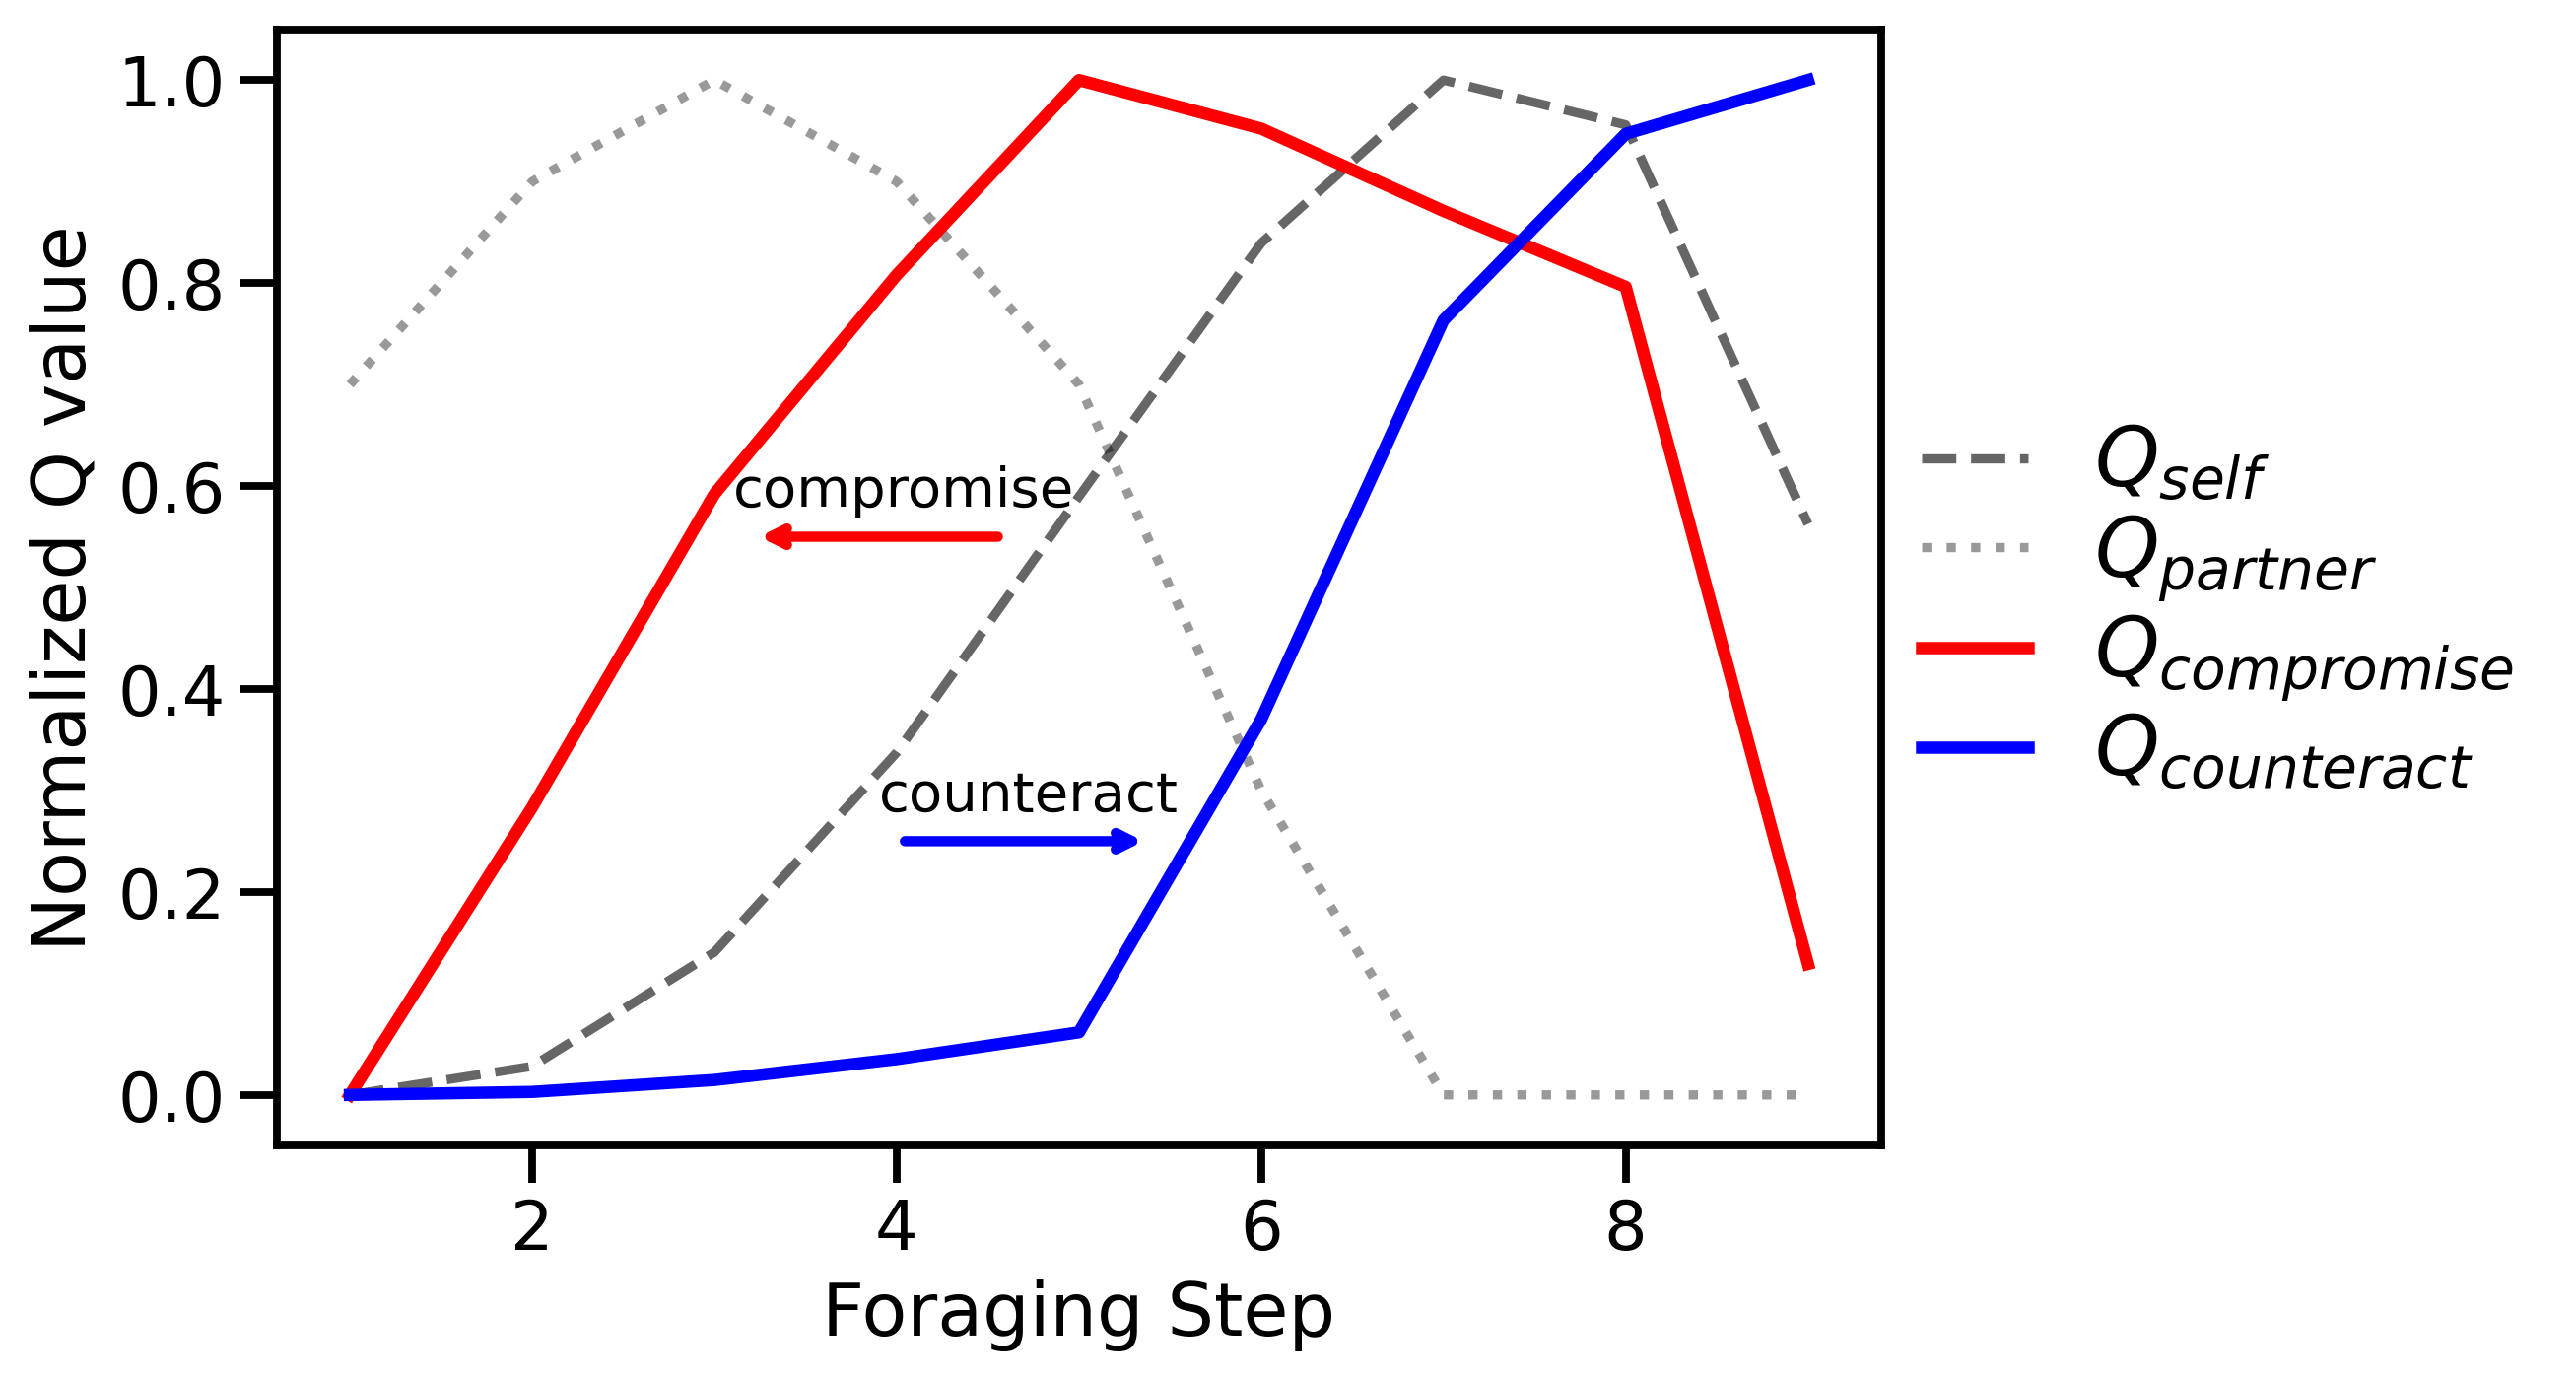

In [3]:
#how this model work?
sns.set_context("talk")
#game setups
X = np.arange(1, 10)
rewards = X ** 2
#set params
w1 = 0.41
theta = 1.5
#set v_safety
V_safety = np.array([0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1])
#get Q_self
Q_self = V_safety * rewards ** theta - (1 - V_safety) * 10 ** theta
Q_self = (Q_self - min(Q_self)) / (max(Q_self) - min(Q_self))
#get Q_partner
pred_other_step = 3
Q_partner = np.array([max(1.1 - 0.1 * 2 ** abs(i - pred_other_step), 0) for i in X])
Q = w1 * Q_partner + (1-w1) * Q_self
Q1 = (Q - min(Q)) / (max(Q) - min(Q))
# Q = np.array([max(Q_self[i-1] - w * np.sqrt(abs(i - pred_other_step)), 0) for i in X])

w2 = -0.9
compensate = max(min(2 * np.argmax(Q_self) - pred_other_step, 0), 9)
Q_partner_c = np.array([max(1.1 - 0.1 * 2 ** abs(i - compensate), 0) for i in X])
Q = -w2 * Q_partner_c + (1+w2) * Q_self
Q2 = (Q - min(Q)) / (max(Q) - min(Q))
# w2=0.5
# Q2 = w2 * Q_partner + (1-w2) * Q_self
# Q2 = (Q2 - min(Q2)) / (max(Q2) - min(Q2))
# normalize Q?
# beta = 5
# Q_self = np.exp(Q_self * beta) / np.sum(np.exp(Q_self * beta))
# Q = np.exp(Q * beta) / np.sum(np.exp(Q * beta))
# Q_partner= Q_partner / sum(Q_partner)

# colors = ['firebrick', 'steelblue']
colors = ['red', 'blue'] 
plt.figure(figsize=(7, 5), dpi=300)
plt.plot(X, Q_self, label='$Q_{self}$', ls='--', color='black', alpha=0.6)
plt.plot(X, Q_partner, label='$Q_{partner}$', ls=':', color='black', alpha=0.4)
plt.plot(X, Q1, label = '$Q_{compromise}$', ls='-', color=colors[0], linewidth=3) #, marker='o'
plt.plot(X, Q2, label = '$Q_{counteract}$', ls='-', color=colors[1], linewidth=3)
plt.xlabel('Foraging Step')
plt.ylabel('Normalized Q value')
plt.legend(fontsize=20, labelspacing=0.1, loc='lower center', handlelength=1.3,
           bbox_to_anchor=(1.21, 0.25), frameon=False)

#annotate
plt.annotate("compromise", xy=(3.1, 0.58), fontsize=13.5)
plt.annotate("", xy=(3.2, 0.55), xytext=(4.6, 0.55), 
             arrowprops=dict(arrowstyle="->", color=colors[0], lw=2.5))
plt.annotate("counteract", xy=(3.9, 0.28), fontsize=13.5)
plt.annotate("", xy=(5.4, 0.25), xytext=(4.0, 0.25), 
             arrowprops=dict(arrowstyle="->", color=colors[1], lw=2.5))
plt.show()

In [9]:
# read any df_idv as example
df_idv = pd.read_csv('../processed_data/parsed_idv.csv')

predator 0 : 8, predator 1 : 5


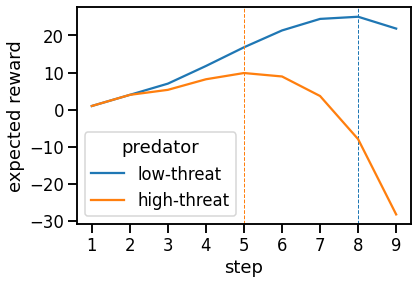

In [10]:
#plot optimal
optimal = []
predators=['low-threat', 'high-threat']
for pt in [0, 1]:
    attack_prob = df_idv.query('predatorType==@pt and choice>0').groupby(['choice'], as_index=False)['currProb'].mean()
    values = (1 - attack_prob['currProb'].values) * (attack_prob['choice'] ** 2) - attack_prob['currProb'].values * 10
    plt.plot(values, c=sns.color_palette()[pt], label=predators[pt])
    opt_step = np.argmax(values)
    plt.axvline(opt_step, ls='--', color=sns.color_palette()[pt], lw=1)
    optimal.append(opt_step + 1) #turn to 1-indexed

plt.xticks(np.arange(9), np.arange(9)+1)
plt.xlabel('step')
plt.ylabel('expected reward')
plt.legend(title='predator')


# compromise by optimality
print(f"predator 0 : {optimal[0]}, predator 1 : {optimal[1]}")


[0.5264999270439148, 0.4320000410079956]


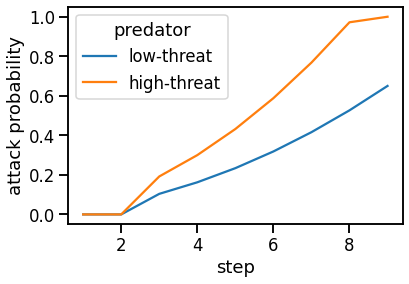

In [11]:
#plot attack rate
optimal_att = []
predators=['low-threat', 'high-threat']
for pt in [0, 1]:
    attack_prob = df_idv.query('predatorType==@pt and choice>0').groupby(['choice'])['currProb'].mean()
    attack_prob[attack_prob>1] = 1
    
    optimal_att.append(attack_prob[optimal[pt]])
    plt.plot(attack_prob, c=sns.color_palette()[pt], label=predators[pt])
    
# plt.xticks(np.arange(9), np.arange(9)+1)
plt.xlabel('step')
plt.ylabel('attack probability')
plt.legend(title='predator')
print(optimal_att)


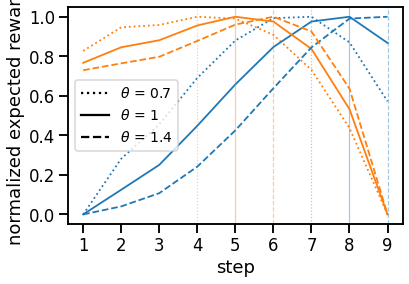

In [12]:
# plot EV: show effet of Theta
optimal = []
lss = [':', '-', '--']
thetas = [0.7, 1, 1.4]

for t, theta in enumerate(thetas):
    for pt in [0, 1]:
        attack_prob = df_idv.query('predatorType==@pt and choice>0').groupby(['choice'], as_index=False)['currProb'].mean()
        values = (1 - attack_prob['currProb'].values) * (attack_prob['choice'] ** 2) ** theta - attack_prob['currProb'].values * (10 ** theta)
        plt.plot((values - np.min(values)) / (np.max(values) - np.min(values)), ls=lss[t], c=sns.color_palette()[pt], lw=1.8)
        plt.axvline(x=np.argmax(values),ls=lss[t], c=sns.color_palette()[pt], alpha=0.4, lw=1.2)

plt.xticks(np.arange(9), np.arange(9)+1)
plt.xlabel('step')
plt.ylabel('normalized expected reward')


legend_handles = [
    Line2D([0], [0], color='black', ls=lss[i], label=rf"$\theta$ = {thetas[i]}")
    for i in range(len(lss))
]

plt.legend(handles=legend_handles, loc='center left', fontsize=14)
